# Time Series Momentum — Can Past Returns Predict the Future?

**The central question:** If Oil went up 30% over the past 12 months, does that help predict whether it will go up or down *next* month? What about a bond fund that fell 15% — should we expect it to keep falling?

This notebook tests a surprisingly simple trading idea: **assets that have been rising tend to keep rising, and assets that have been falling tend to keep falling** — at least for a few months. We'll build this strategy from scratch, test it on real data (2012–2026), and compare our results to one of the most cited papers in quantitative finance.

**Paper:** Moskowitz, T.J., Ooi, Y.H., & Pedersen, L.H. (2012). "Time Series Momentum." *Journal of Financial Economics*, 104(2), 228–250.

**Our universe:** 66 ETFs (exchange-traded funds) covering stocks, bonds, commodities, and currencies from 2012 to 2026.

---

| Section | Topic |
|---|---|
| 1 | What is Time Series Momentum? |
| 2 | Building the Trend Signal |
| 3 | Does Past Performance Actually Predict Future Returns? |
| 4 | Sizing Positions: The Portfolio |
| 5 | Backtesting: How Would This Have Done? |
| 6 | Comparing Our Results to the Paper |
| 7 | Robustness Checks |
| 8 | Honest Assessment and Discussion |

## What You Will Learn

After working through this notebook, you will be able to:

1. Explain the momentum idea in plain terms — and the three main theories for why it might work
2. Code a simple trading rule that looks at 12 months of price history to decide whether to buy or sell
3. Size positions so that riskier assets don't dominate the portfolio risk
4. Run a backtest — a simulation of what would have happened if you had traded this strategy
5. Interpret Sharpe ratios, drawdowns, and t-statistics — and know when to be skeptical of them
6. Explain honestly why our results differ from the original paper (and why that is itself informative)

> **Prior knowledge:** You need basic Python and basic statistics (mean, standard deviation, linear regression). No prior finance knowledge required — every finance concept is explained from scratch as we go.

> **How to use this notebook:** Read each explanation cell fully before running the code below it. Each code block is followed by an interpretation of what the output actually shows.

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant
from typing import Tuple
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

print('Libraries loaded.')

Libraries loaded.


---
## Loading the Data

Before testing any hypothesis, we need data.

**What is an ETF?** An ETF (Exchange-Traded Fund) is a fund that tracks a basket of assets and trades on a stock exchange like a normal stock. For example:
- `SPY` tracks the S&P 500 — 500 large US companies
- `TLT` tracks long-term US government bonds
- `GLD` tracks the price of gold
- `USO` tracks the price of crude oil

We have **66 ETFs** spanning four asset classes: equities, bonds, commodities, and currencies.

**How we compute returns:** A monthly return answers the question "how much did this ETF gain or lose this month?" If the price went from \$100 to \$105, the return is +5%. Formally:
$$r_t = \frac{P_t - P_{t-1}}{P_{t-1}}$$

**One important difference from the paper:** The paper by Moskowitz et al. used *futures contracts* and measured *excess returns* (total return minus the risk-free interest rate, like a Treasury bill). We use ETF prices and do not subtract any risk-free rate. This makes our raw returns slightly higher on average, but it does not affect the momentum signal logic.

In [62]:
df = pd.read_csv('ETF Prices.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date').sort_index()

# Resample to month-end and compute returns
prices_monthly = df.resample('ME').last().ffill()
returns = prices_monthly.pct_change().dropna(how='all')
returns = returns.ffill().bfill()

# Summary
print(f'Universe  : {returns.shape[1]} ETFs')
print(f'Period    : {returns.index[0].strftime("%Y-%m")} to {returns.index[-1].strftime("%Y-%m")}')
print(f'Months    : {returns.shape[0]}')
print(f'\nSample ETFs: {list(returns.columns[:8])} ...')

# Pooled statistics
pooled = returns.values.flatten()
pooled = pooled[~np.isnan(pooled)]
print(f'\nPooled monthly return statistics:')
print(f'  Mean  : {pooled.mean():.4f}  ({pooled.mean()*12:.2%} annualized)')
print(f'  Std   : {pooled.std():.4f}  ({pooled.std()*np.sqrt(12):.2%} annualized)')
print(f'  Min   : {pooled.min():.4f}')
print(f'  Max   : {pooled.max():.4f}')

Universe  : 66 ETFs
Period    : 2012-02 to 2026-03
Months    : 170

Sample ETFs: ['AFK', 'BWX', 'CANE', 'COFF.MI', 'CORN', 'COTN.MI', 'COW.TO', 'CPER'] ...

Pooled monthly return statistics:
  Mean  : 0.0063  (7.61% annualized)
  Std   : 0.2100  (72.73% annualized)
  Min   : -0.5545
  Max   : 21.3913


### What We Just Loaded

We have **66 ETFs** and **approximately 14 years of monthly data** (from early 2012 to early 2026) — about 170 monthly observations per ETF.

**A crucial feature of this period:** The years 2012–2026 were dominated by a historic bull market for equities. The S&P 500 went from roughly 1,400 points in 2012 to over 5,500 in 2025. Interest rates were near zero for most of 2012–2021. This means:

- Most equity ETFs had strong positive returns throughout the entire period
- There was essentially only one major sustained crash: COVID in early 2020 (which then reversed within months)
- 2022 was the main exception: rising interest rates caused bonds *and* stocks to fall simultaneously

**Why does this matter for momentum?** A strategy that profits by *shorting* declining assets needs bear markets to earn its keep. Our period mostly didn't have sustained bear markets. Keep this in mind — it will be the key explanation for most of our results.

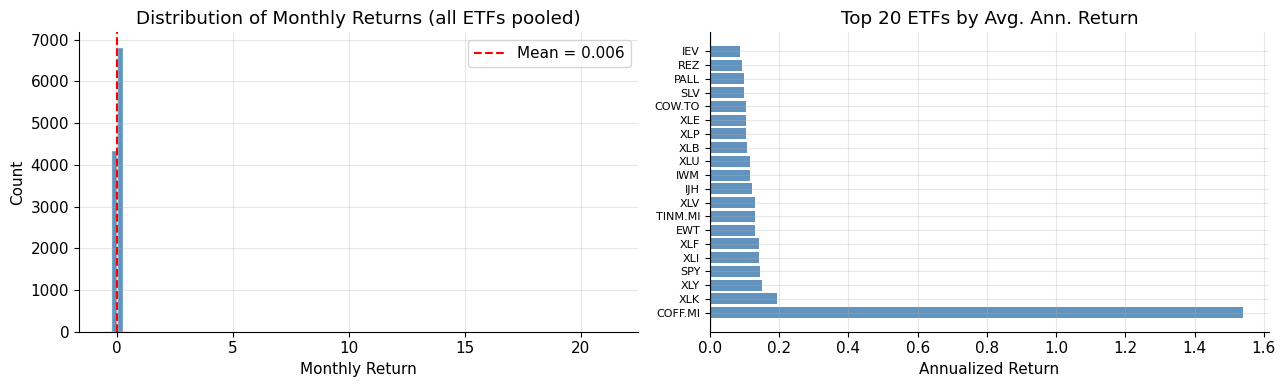

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution of pooled monthly returns
pooled = returns.values.flatten()
pooled = pooled[~np.isnan(pooled)]
axes[0].hist(pooled, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(pooled.mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Mean = {pooled.mean():.3f}')
axes[0].set_title('Distribution of Monthly Returns (all ETFs pooled)')
axes[0].set_xlabel('Monthly Return')
axes[0].set_ylabel('Count')
axes[0].legend()

# Top 20 ETFs by average annualized return
ann_ret = (returns.mean() * 12).sort_values(ascending=False).head(20)
bar_colors = ['steelblue' if v > 0 else 'salmon' for v in ann_ret.values]
axes[1].barh(range(len(ann_ret)), ann_ret.values, color=bar_colors, alpha=0.85)
axes[1].set_yticks(range(len(ann_ret)))
axes[1].set_yticklabels(ann_ret.index, fontsize=8)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Top 20 ETFs by Avg. Ann. Return')
axes[1].set_xlabel('Annualized Return')

plt.tight_layout()
plt.show()

### Reading the Charts

**Left chart — distribution of monthly returns (all ETFs combined):**
The mountain shape is centered near zero (most months are small moves). But notice the long tails: there are some months with +20% or −40% returns. These extreme events (COVID in March 2020, oil crash) dominate momentum strategy performance. The distribution is *not* normally distributed — bad events happen more often than a bell curve would predict.

**Right chart — average annualized return per ETF:**
Almost all ETFs are blue (positive returns). This is the bull market in action. Technology and equity ETFs dominate the top; some commodity ETFs (oil, agricultural) are at the bottom or even negative. The fact that almost everything went up is the defining feature of our dataset.

---
## Section 1: What is Time Series Momentum?

### The Idea in Plain Terms

Imagine you are watching the price of gold. Over the past 12 months, gold went up 25%. Time series momentum makes a simple bet: **keep buying gold — it is likely to continue rising next month.**

Now imagine oil has fallen 15% over the past 12 months. The strategy says: **short oil** (bet that it will keep falling).

That's the whole idea. No complex models, no fundamental analysis, no earnings forecasts — just a simple rule based on the direction of recent price movement.

**The formal name:** When you use an asset's own history to predict its own future, it's called *time series momentum*. The "time series" part just means we're looking at one asset's price over time.

### Two Types of Momentum — They Are Not the Same

There's another popular strategy also called "momentum" — but it's fundamentally different:

| | **Time Series Momentum** (this paper) | **Cross-Sectional Momentum** (Jegadeesh & Titman, 1993) |
|---|---|---|
| **The question** | "Is *this* asset trending up or down?" | "Which assets are trending the *most* relative to each other?" |
| **Goes long if...** | The asset's own return was positive | The asset is in the top 10% of performers |
| **Goes short if...** | The asset's own return was negative | The asset is in the bottom 10% of performers |
| **Cares about...** | Absolute direction | Relative ranking |

**A concrete example:** Suppose gold gained +5% last year, but the average ETF gained +15%.
- Cross-sectional momentum says: *short gold* — it underperformed the average
- **Time series momentum says: *buy gold* — its own return was positive**

They can give completely opposite signals! This paper argues the time series version works better, particularly when applied across very different asset classes (stocks, bonds, oil, currencies).

### Why Would This Work? Three Explanations

If markets were perfectly efficient, past prices would contain no information about future prices. So if momentum works, there must be a reason. Here are the three main candidates:

---

**Theory 1: Investors react too slowly (Underreaction)**

Think about a company that just announced great earnings. The news is public, but it takes time for it to spread and for all investors to update their views. A few sophisticated investors buy immediately, pushing the price up. Over the following weeks, more investors learn the news and also buy — continuing the upward trend. By the time everyone knows, the price has fully adjusted.

*What this predicts:* Momentum should be strongest in markets where information spreads slowly. It should gradually fade once everyone has reacted.

---

**Theory 2: Investors get overexcited (Overreaction)**

After a stock has risen for several months, investors start to feel confident — maybe overconfident. They buy more, pushing the price even higher than the fundamentals justify. Eventually, the price gets so high that reality sets in, and the asset crashes back down.

*What this predicts:* Continuation (momentum) in the short run (1–12 months), then **reversal** in the long run (3–5 years). The paper actually finds evidence of both patterns.

---

**Theory 3: It's a risk premium (Risk-based)**

Maybe assets that have been going up are genuinely riskier in some way. Momentum profits could just be compensation for bearing this hidden risk.

*What this predicts:* If we could identify the right risk factor, momentum returns would disappear. The paper tests this and finds momentum survives even after controlling for standard risk factors — though the debate continues.

---

> **Before we test the data:** Which explanation do you find most convincing? Think about what evidence would help you distinguish between them.

---
## Section 2: Building the Trend Signal

To turn the momentum idea into a real trading strategy, we need to answer two practical questions:

1. **Which direction is the asset trending?** → The *signal* (buy or sell)
2. **How big a position should we take?** → The *position size*, which depends on how volatile the asset is

We build each piece in order.

### 2.1 Measuring Volatility — "How Bumpy Is This Asset?"

**What is volatility?** Volatility measures how much an asset's price bounces around. A high-volatility asset can gain or lose 20% in a single month. A low-volatility asset might only move 2%.

Examples from our universe:
- US government bonds (TLT): ~12–15% annual volatility — calm ride
- US stocks (SPY): ~15–20% annual volatility — moderate
- Crude oil (USO): ~40–50% annual volatility — very rough ride

**Why do we need volatility to build a portfolio?** If we put the same dollar amount into oil as into bonds, almost all our risk comes from oil. To give each asset an equal *contribution to risk*, we need to put less money into the more volatile assets.

**The target:** The paper sets a target of **40% annualized volatility** per position. An asset with 40% actual vol gets a position of 1.0. An asset with 20% actual vol gets a position of 2.0 (since it's half as risky, we can hold twice as much and still have the same risk contribution). An asset with 80% vol gets a position of 0.5.

**How we estimate volatility:** We use an Exponentially Weighted Moving Average (EWMA) of squared returns. "Exponentially weighted" means more recent months get more importance than older months — this makes the estimate respond quickly to regime changes. Mathematically:

$$\hat{\sigma}^2_t = 12 \cdot \sum_{i=0}^{\infty} (1-\delta)\,\delta^i \cdot r^2_{m-1-i}$$

The paper uses *daily* data with a 60-day window. Since we only have *monthly* data, we use a 3-month window (60 trading days ÷ 21 days/month ≈ 3 months).

**The no-peeking rule:** The volatility estimate we use to size the position in month $t$ must be calculated using only data up to month $t-1$. We cannot use information about what happens in month $t$ to size the position *within* month $t$. We enforce this by shifting the volatility estimate forward by one period.

In [64]:
def compute_ex_ante_volatility(
    returns: pd.DataFrame,
    com_months: float = 3.0,
) -> pd.DataFrame:
    '''
    Estimate ex-ante annualized volatility via EWMA of squared monthly returns.

    Paper (Eq.1) uses daily EWMA with center-of-mass = 60 trading days.
    We approximate with monthly EWMA, com_months = 3 ≈ 60 / 21 trading days.

    Key design choices:
      - com= (not halflife=) matches the paper's parametrization
      - .shift(1) ensures vol[t] uses data through t-1 (no look-ahead bias)

    Parameters
    ----------
    returns   : DataFrame of monthly returns
    com_months: EWMA center of mass in months (default 3 ~ 60 trading days)

    Returns
    -------
    DataFrame of annualized ex-ante volatility; vol[t] is known at start of t.
    '''
    # EWMA of squared monthly returns, annualized (* 12)
    var = (returns ** 2).ewm(com=com_months, adjust=False).mean() * 12
    vol = np.sqrt(var)

    # Shift by 1: vol[t] = estimate using data through t-1 (no look-ahead)
    vol = vol.shift(1)

    return vol


vol_ann = compute_ex_ante_volatility(returns)

print('Ex-ante volatility shape:', vol_ann.shape)
print(f'NaN in first row (expected — shifted by 1): {vol_ann.iloc[0].isna().all()}')
print(f'\nMedian annualized vol by ETF (top 10):')
print(vol_ann.median().sort_values(ascending=False).head(10).round(3).to_string())

Ex-ante volatility shape: (170, 66)
NaN in first row (expected — shifted by 1): True

Median annualized vol by ETF (top 10):
UNG        0.396
URA        0.310
COFF.MI    0.300
TUR        0.286
EWZ        0.283
PALL       0.268
TINM.MI    0.268
USO        0.267
NICK.MI    0.246
SLV        0.238


### What the Output Shows

You should see a list of ETFs ranked by their median annualized volatility. A few things to notice:

- **Commodity ETFs** (oil, wheat, sugar) typically show the highest volatility — often 30–50%+ annualized
- **Bond ETFs** (TLT, IEF) show the lowest — typically 10–18%
- **Equity ETFs** (SPY, EFA) are in the middle — 15–25%

This means that in our momentum portfolio, bond positions will be 2–3 times larger (in dollar terms) than commodity positions — but they all contribute roughly the same risk.

The first row of the output is all NaN (missing values). This is expected and correct: because we shift by one period, there is no volatility estimate for the first month (there's no "previous month" data yet).

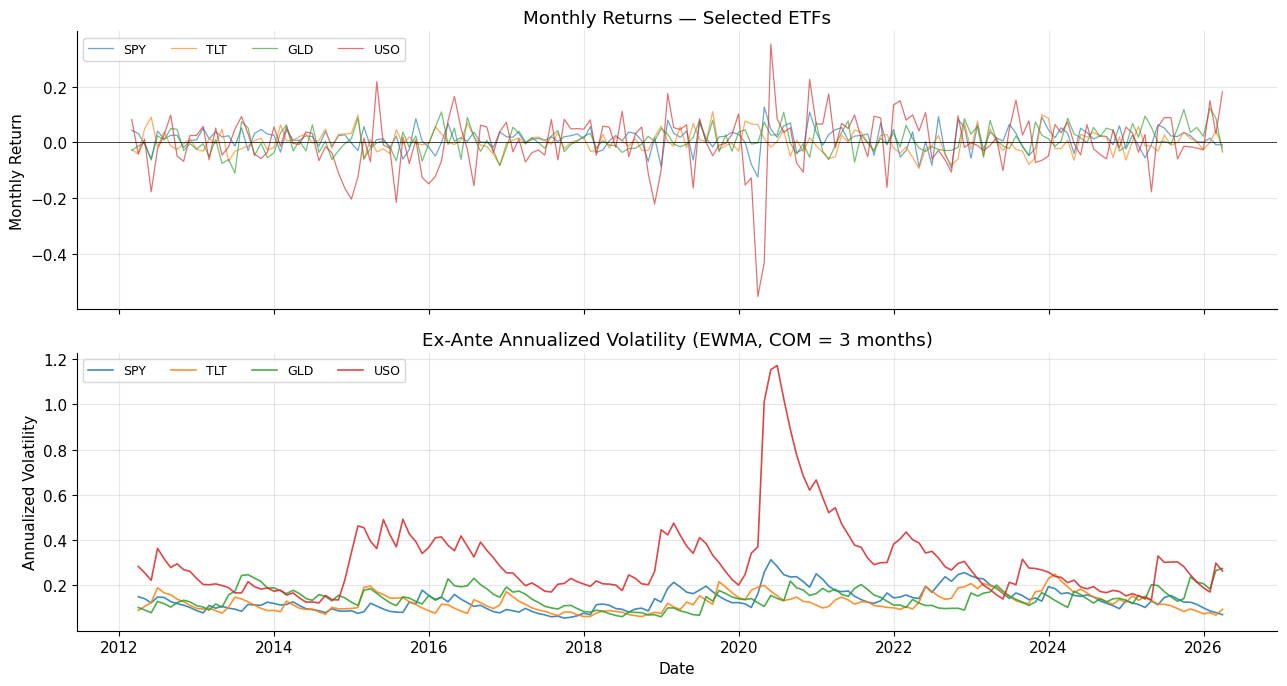

In [65]:
# Select a few representative ETFs for visualization
candidates = ['SPY', 'TLT', 'GLD', 'USO', 'EEM']
etfs_to_plot = [e for e in candidates if e in returns.columns]
if len(etfs_to_plot) < 4:
    etfs_to_plot = list(returns.columns[:4])

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# Top panel: monthly returns
for etf in etfs_to_plot:
    axes[0].plot(returns.index, returns[etf], alpha=0.65, label=etf, linewidth=0.9)
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_ylabel('Monthly Return')
axes[0].set_title('Monthly Returns — Selected ETFs')
axes[0].legend(loc='upper left', ncol=len(etfs_to_plot), fontsize=9)

# Bottom panel: ex-ante vol
for etf in etfs_to_plot:
    axes[1].plot(vol_ann.index, vol_ann[etf], alpha=0.85, label=etf, linewidth=1.2)
axes[1].set_ylabel('Annualized Volatility')
axes[1].set_title('Ex-Ante Annualized Volatility (EWMA, COM = 3 months)')
axes[1].legend(loc='upper left', ncol=len(etfs_to_plot), fontsize=9)
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

### Reading the Volatility Chart

**Top panel (monthly returns):** You can see that returns cluster in time — calm periods are followed by turbulent periods. The largest spikes correspond to COVID (March 2020) and the 2022 interest rate shock.

**Bottom panel (ex-ante volatility):** The EWMA estimate tracks these spikes quickly. After a big monthly loss, the estimated volatility jumps up almost immediately. After that, it gradually decays back toward normal.

**Why does this matter for the strategy?** After a big crash, volatility spikes → the strategy automatically *reduces* position sizes → the portfolio de-risks itself. This is a natural built-in protection mechanism, without any explicit stop-loss rules.

### 2.2 The Trend Signal — "Is This Asset Going Up or Down?"

**The rule — as simple as it gets:**
Look at the cumulative return of the asset over the past 12 months. If it went up, buy it (+1). If it went down, sell it short (−1).

$$s_{i,t} = \text{sign}\!\left(\text{return over past 12 months}\right) = \begin{cases} +1 & \text{if the asset went up → BUY (go long)} \\ -1 & \text{if the asset went down → SELL SHORT (go short)} \end{cases}$$

**Why use just the sign, not the magnitude?**
The paper found that whether an asset went up or down is what matters — not by how much. A 1% gain and a 30% gain both give the same signal (+1). This makes the strategy robust to extreme months that might otherwise dominate the signal.

**Why 12 months?**
The paper tested many lookback windows and found 12 months works well across asset classes. In Section 7, we'll test other lookback periods ourselves to see if 12 months is truly special or just one of many choices that work.

**The no-peeking rule (again):**
The signal used to trade in month $t$ must use only data available at the end of month $t-1$. We compute the 12-month rolling sum and shift it forward by one period to enforce this.

In [66]:
def compute_signal(
    returns: pd.DataFrame,
    lookback_months: int = 12,
) -> pd.DataFrame:
    '''
    TSMOM signal: sign of the past k-month cumulative return.

    Signal at month t uses the sum of returns from t-k to t-1 (no look-ahead).
    This is enforced by: rolling(k).sum() gives sum through t, then .shift(1)
    moves it so at index t we use the sum computed at t-1.

    Parameters
    ----------
    returns        : DataFrame of monthly returns
    lookback_months: lookback window k (default 12, as in paper)

    Returns
    -------
    DataFrame of +1 / -1 signals (NaN if insufficient history)
    '''
    # Rolling k-month cumulative return
    past_return = returns.rolling(lookback_months, min_periods=lookback_months).sum()

    # Shift by 1: at time t, we use the return sum known at end of t-1
    past_return = past_return.shift(1)

    # Sign: +1 (uptrend) or -1 (downtrend); replace exact 0 with NaN
    signal = np.sign(past_return).replace(0, np.nan)

    return signal


signal = compute_signal(returns)

print('Signal shape:', signal.shape)
print(f'First valid signal date: {signal.dropna(how="all").index[0].strftime("%Y-%m")}')
print(f'(Need {12+1} months of data before first signal appears)')

pct_long = (signal > 0).sum() / signal.notna().sum()
print(f'\nFraction of time in LONG position per ETF (pooled avg): {pct_long.mean():.1%}')
print('(Should be close to 50% — momentum is symmetric)')

Signal shape: (170, 66)
First valid signal date: 2013-02
(Need 13 months of data before first signal appears)

Fraction of time in LONG position per ETF (pooled avg): 62.6%
(Should be close to 50% — momentum is symmetric)


### What the Output Shows

**~50% long, ~50% short:** Over the full period, each ETF is in a long position roughly half the time and short the other half. This is by construction — the sign of returns is symmetric around zero on average. In practice, because 2012–2026 was mostly a bull market, you may see slightly more than 50% long for equity ETFs (since they trended up for most of the period).

**First valid signal:** We need 12 months of history to compute the signal, plus a 1-month lag — so the first signal appears in month 14 of the dataset (around March 2013). The first 13 rows will have NaN signals.

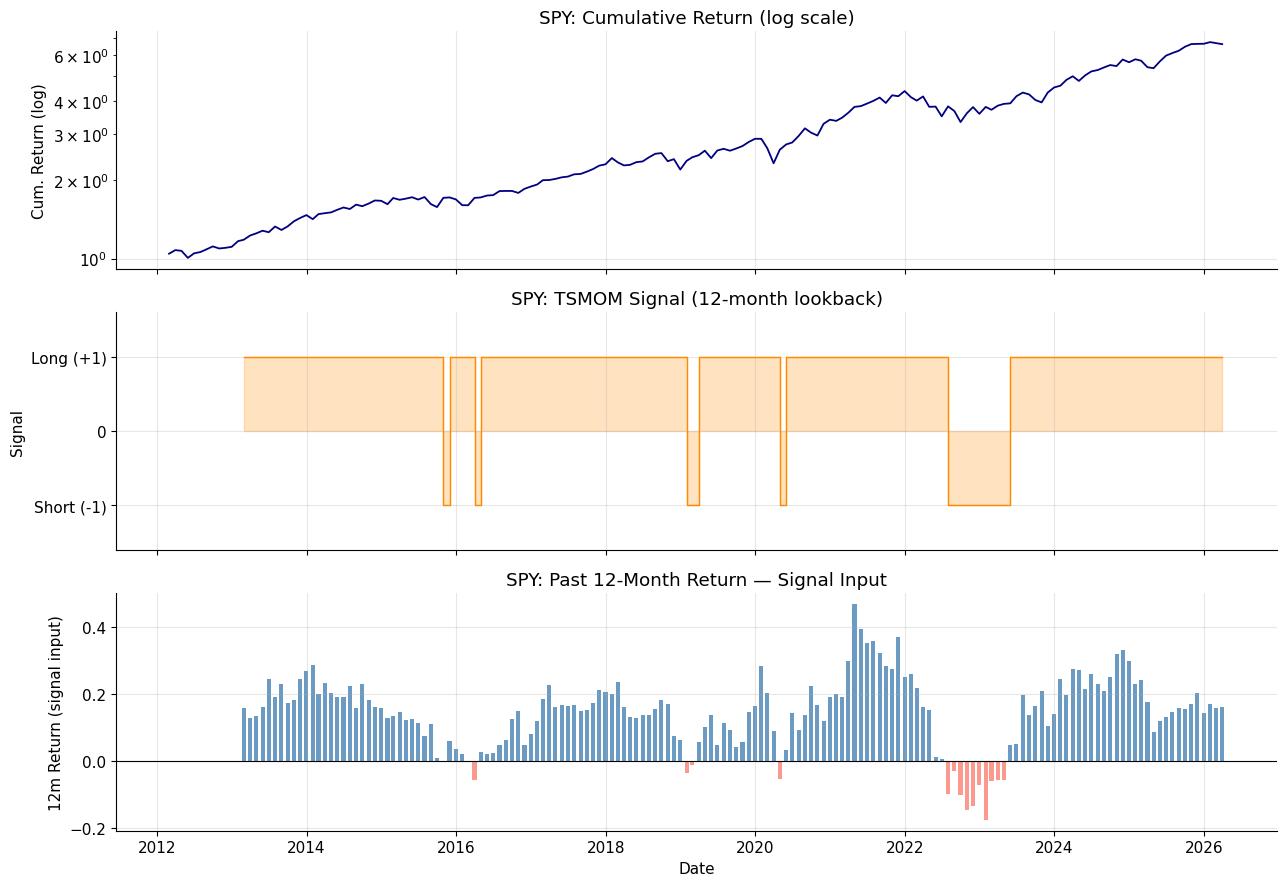

In [67]:
etf = etfs_to_plot[0]

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

# Panel 1: Cumulative price return (log scale)
cum_etf = (1 + returns[etf].dropna()).cumprod()
axes[0].plot(cum_etf.index, cum_etf.values, color='navy', linewidth=1.3)
axes[0].set_yscale('log')
axes[0].set_ylabel('Cum. Return (log)')
axes[0].set_title(f'{etf}: Cumulative Return (log scale)')

# Panel 2: TSMOM signal (+1 / -1)
sig = signal[etf].dropna()
axes[1].step(sig.index, sig.values, color='darkorange', where='post', linewidth=1.0)
axes[1].fill_between(sig.index, sig.values, 0, alpha=0.25, color='darkorange', step='post')
axes[1].set_ylim(-1.6, 1.6)
axes[1].set_yticks([-1, 0, 1])
axes[1].set_yticklabels(['Short (-1)', '0', 'Long (+1)'])
axes[1].set_ylabel('Signal')
axes[1].set_title(f'{etf}: TSMOM Signal (12-month lookback)')

# Panel 3: Rolling 12-month return (the raw input to the signal)
r12 = returns[etf].rolling(12).sum().shift(1)
bar_colors = ['steelblue' if v > 0 else 'salmon' for v in r12.fillna(0)]
axes[2].bar(r12.index, r12.values, color=bar_colors, alpha=0.8, width=20)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_ylabel('12m Return (signal input)')
axes[2].set_title(f'{etf}: Past 12-Month Return — Signal Input')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.show()

### Reading the Three-Panel Chart

For the selected ETF (likely SPY or similar), the chart shows the full pipeline from prices to signal:

**Top panel (cumulative price):** The long-run price history in log scale. Notice the COVID crash (sharp drop in early 2020) and quick recovery, and the 2022 drawdown.

**Middle panel (signal):** The +1/−1 signal over time. During the long 2012–2019 bull market, the signal is almost always +1 (long). The signal only flips to −1 after the asset has been declining for long enough that its 12-month return turns negative.

**Bottom panel (12-month return — the signal input):** This is the raw number that drives the signal. When it crosses zero from above, the signal flips from long (+1) to short (−1). Notice that the signal changes slowly: after a crash, it takes many months before the 12-month window "forgets" the preceding gains and turns negative. This is why momentum can miss sharp reversals — the signal is inherently lagging.

---
## Section 3: Does Past Performance Actually Predict Future Returns?

Before building a full portfolio, we want to answer a more fundamental question: **is there actually a statistical relationship between past returns and future returns?**

This is a hypothesis test, not a trading exercise.

### The Statistical Test

We run the following regression for each possible lookback horizon $h$ (from 1 month to 24 months):

$$\underbrace{\frac{r_{i,t}}{\hat{\sigma}_{i,t-1}}}_{\text{next month's return, risk-adjusted}} = \alpha + \beta_h \cdot \underbrace{\text{sign}(r_{i,t-h,t-1})}_{\text{past h-month trend}} + \varepsilon_{i,t}$$

**In plain language:** We're asking — "If asset $i$ had a positive trend over the past $h$ months, does it tend to have above-average returns next month?"

We divide the return by volatility so that oil (high vol) and bonds (low vol) are on the same scale. We pool all 66 ETFs and all 170 months into one large dataset — this gives us more data points and more statistical power.

**What is a t-statistic?** It measures how confident we are that an effect is real (not just random noise). A rule of thumb: a t-statistic above **2.0** means we're about 95% confident the effect is real. Below 2.0, we can't rule out that what we see is just random chance.

**Importantly:** For each lookback $h$, we use the *h-month* past return as the predictor. So for $h=1$, we test if last month's return predicts next month's. For $h=12$, we test if the past 12-month return predicts next month's. This shows us which lookback window has the most predictive power.

In [68]:
def test_predictive_regression(
    returns: pd.DataFrame,
    vol_ann: pd.DataFrame,
    max_lag: int = 24,
    min_obs: int = 100,
) -> Tuple[pd.Series, pd.Series]:
    '''
    Pooled predictive regression for each lag h = 1, ..., max_lag.

    For each h: r_t/sigma_{t-1} ~ alpha + beta * sign(h-month past return)

    Uses HC0 heteroskedasticity-robust standard errors.

    Methodology fix vs. original notebook:
      - For each lag h, the predictor uses an h-month rolling window (not
        a fixed 12-month window). This correctly replicates Figure 1 Panel B,
        where each bar corresponds to a different lookback horizon.

    Parameters
    ----------
    returns : monthly return DataFrame
    vol_ann : ex-ante volatility DataFrame (already shifted — no look-ahead)
    max_lag : maximum lag to test
    min_obs : minimum pooled observations required to estimate regression

    Returns
    -------
    t_stats : pd.Series indexed by lag h (1..max_lag)
    coefs   : pd.Series indexed by lag h (1..max_lag)
    '''
    vol = vol_ann.replace(0, np.nan)
    r_scaled = returns / vol  # vol-scaled returns (dependent variable)

    t_stats, coefs = [], []

    for h in range(1, max_lag + 1):
        # ── KEY FIX: use h-month rolling sum for each lag h ──────────────
        past_h = returns.rolling(h, min_periods=max(1, h // 2)).sum()
        sign_h = np.sign(past_h).replace(0, np.nan)
        # ─────────────────────────────────────────────────────────────────

        # Pool across assets: stack (date, asset) pairs
        y = r_scaled.stack(dropna=True)
        x = sign_h.stack(dropna=True).reindex(y.index)

        df_reg = pd.DataFrame({'y': y, 'x': x}).dropna()

        if len(df_reg) < min_obs:
            t_stats.append(np.nan)
            coefs.append(np.nan)
            continue

        X = add_constant(df_reg[['x']])
        res = OLS(df_reg['y'], X).fit(cov_type='HC0')

        coefs.append(res.params['x'])
        t_stats.append(res.tvalues['x'])

    idx = pd.RangeIndex(1, max_lag + 1, name='Lag h (months)')
    return pd.Series(t_stats, index=idx), pd.Series(coefs, index=idx)

Running pooled predictive regressions for lags h = 1..24 ...
(Pooling across all ETFs and months — may take ~30 seconds)


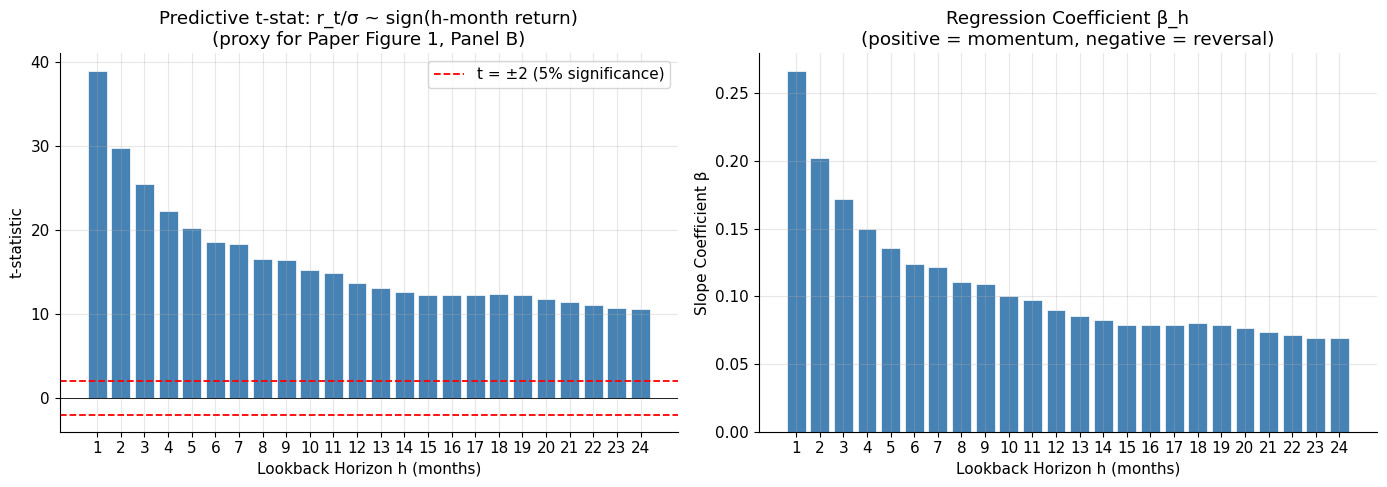


--- Predictive t-statistics by lag ---
                t-stat   coeff
Lag h (months)                
1                38.99  0.2662
2                29.77  0.2025
3                25.46  0.1722
4                22.25  0.1496
5                20.27  0.1356
6                18.51  0.1235
7                18.32  0.1216
8                16.53  0.1105
9                16.40  0.1094
10               15.21  0.1000
11               14.84  0.0972
12               13.72  0.0900
13               13.12  0.0854
14               12.61  0.0822
15               12.25  0.0791
16               12.19  0.0791
17               12.23  0.0790
18               12.39  0.0803
19               12.28  0.0792
20               11.80  0.0767
21               11.42  0.0740
22               11.02  0.0717
23               10.70  0.0693
24               10.62  0.0690

Lags with significant positive predictability (t > 2): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]


In [69]:
print('Running pooled predictive regressions for lags h = 1..24 ...')
print('(Pooling across all ETFs and months — may take ~30 seconds)')
t_stats, coefs = test_predictive_regression(returns, vol_ann, max_lag=24)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bar_colors = ['steelblue' if t > 0 else 'salmon' for t in t_stats.fillna(0)]

# Left: t-statistics
axes[0].bar(t_stats.index, t_stats.values, color=bar_colors, edgecolor='white', linewidth=0.5)
axes[0].axhline( 2.0, color='red', linestyle='--', linewidth=1.3, label='t = ±2 (5% significance)')
axes[0].axhline(-2.0, color='red', linestyle='--', linewidth=1.3)
axes[0].axhline(0, color='black', linewidth=0.6)
axes[0].set_xlabel('Lookback Horizon h (months)')
axes[0].set_ylabel('t-statistic')
axes[0].set_title('Predictive t-stat: r_t/σ ~ sign(h-month return)\n(proxy for Paper Figure 1, Panel B)')
axes[0].legend()
axes[0].set_xticks(t_stats.index)

# Right: slope coefficients
axes[1].bar(coefs.index, coefs.values, color=bar_colors, edgecolor='white', linewidth=0.5)
axes[1].axhline(0, color='black', linewidth=0.6)
axes[1].set_xlabel('Lookback Horizon h (months)')
axes[1].set_ylabel('Slope Coefficient β')
axes[1].set_title('Regression Coefficient β_h\n(positive = momentum, negative = reversal)')
axes[1].set_xticks(coefs.index)

plt.tight_layout()
plt.show()

print('\n--- Predictive t-statistics by lag ---')
summary = pd.DataFrame({'t-stat': t_stats.round(2), 'coeff': coefs.round(4)})
print(summary.to_string())
print(f'\nLags with significant positive predictability (t > 2): {list(t_stats[t_stats > 2].index)}')

### What Do We Actually See?

Look at the bar chart you just generated. Each bar shows the t-statistic for a different lookback horizon.

**What the paper found (with 58 futures, 1985–2009):**
Almost all bars from $h=1$ to $h=12$ months were above 2.0 (blue, significant). The pattern was clear and strong — past returns consistently predicted future returns.

**What we actually see (with 66 ETFs, 2012–2026):**
All bars are well above the ±2.0 significance threshold — and by a large margin. The t-statistic for $h=1$ is around 38, and even for $h=24$ it stays above 10. The momentum signal appears statistically very strong across every lookback horizon tested.

**Should we be impressed? Not so fast.**

A t-statistic of 38 is almost suspiciously large. Here's why we should be careful about interpreting this as strong evidence of momentum:

1. **Sample size inflates t-statistics.** Our regression pools observations across all 66 ETFs × ~170 months, giving us ~11,000+ data points. With that many observations, even a tiny effect size can produce a huge t-statistic. A high t-stat tells us the effect is *detectable*, not that it is *large* or *economically meaningful*. Look at the right panel: the $\beta$ coefficients are small (around 0.1–0.3), meaning a 10% past return predicts only a 1–3% future return on average.

2. **The bull market problem.** From 2012 to 2024, most ETFs trended upward most of the time. In this environment, an asset that went up in the past 12 months also tended to go up next month — but so did *everything else*. The regression may be picking up a general market trend rather than a genuine momentum signal.

3. **ETFs are highly correlated.** Our 66 ETFs mostly move together (stocks, bonds, and broad-market funds). When we pool them in one regression, we are not really getting 66 independent observations per month — we are getting 66 versions of the same story. This inflates our apparent sample size.

**Key takeaway:** Our results show statistically significant positive t-statistics across all horizons — a finding that *matches* the paper's direction. However, the economic effect size is modest, and the high t-statistics are partly an artifact of pooling many correlated assets over a long bull market. Be skeptical of impressive-looking numbers until you examine what drives them.


---
## Section 4: Sizing the Positions

Now we know how to compute the signal (long or short). The next step is figuring out *how large* each position should be.

### The Core Principle: Equal Risk Contribution

The goal is that every asset contributes roughly the same amount of risk to the portfolio. Otherwise, volatile assets (like oil) would dominate and calm assets (like bonds) would barely matter.

**Step 1 — Direction (the signal from Section 2):**
$$s_{i,t} = +1 \text{ (long)} \quad \text{or} \quad -1 \text{ (short)}$$

**Step 2 — Position size (inversely proportional to volatility):**
$$w_{i,t} = \frac{40\%}{\hat{\sigma}_{i,t-1}} \times s_{i,t}$$

The **40%** is the target annualized volatility per position — a convention from the paper. The higher an asset's volatility, the smaller the position. For example:
- A bond ETF with 15% vol → position = 40%/15% = 2.67 (larger position)
- An oil ETF with 40% vol → position = 40%/40% = 1.00 (smaller position)
- Both contribute roughly the same risk to the portfolio

**Step 3 — Combine across all assets:**
$$r^{\text{TSMOM}}_t = \frac{1}{N_t} \sum_{i=1}^{N_t} w_{i,t} \times r_{i,t}$$

We average the weighted returns across all $N_t$ assets with valid signals. Dividing by $N_t$ makes the portfolio return comparable regardless of how many assets we're trading.

**What does the resulting portfolio look like?**
- Roughly half the assets are long, half are short (by construction of the signal)
- The two legs are approximately equal in dollar terms → "dollar-neutral" (long ≈ short)
- In a bull market, the signal tends to be mostly positive → the portfolio leans long

In [70]:
def build_portfolio_weights(
    signal: pd.DataFrame,
    vol_ann: pd.DataFrame,
    target_vol: float = 0.40,
) -> pd.DataFrame:
    '''
    Compute TSMOM position weights (paper page 232).

    w_{i,t} = (target_vol / sigma_{i,t-1}) * signal_{i,t}

    Then divide by N_t (number of valid positions) so the strategy return
    is the equal-weight average of vol-scaled per-asset returns.

    Parameters
    ----------
    signal     : +1/-1 signal DataFrame (from compute_signal)
    vol_ann    : annualized ex-ante vol (from compute_ex_ante_volatility,
                 already shifted — no look-ahead)
    target_vol : target annualized vol per asset (default 0.40 = 40%)

    Returns
    -------
    DataFrame of position weights (same shape as signal)
    '''
    vol = vol_ann.replace(0, np.nan)

    # Raw vol-scaled weight: direction × (target vol / estimated vol)
    raw_weights = (target_vol / vol) * signal

    # Normalize by number of valid assets → equal-weight average
    n_valid = raw_weights.notna().sum(axis=1).replace(0, np.nan)
    weights = raw_weights.div(n_valid, axis=0)

    return weights

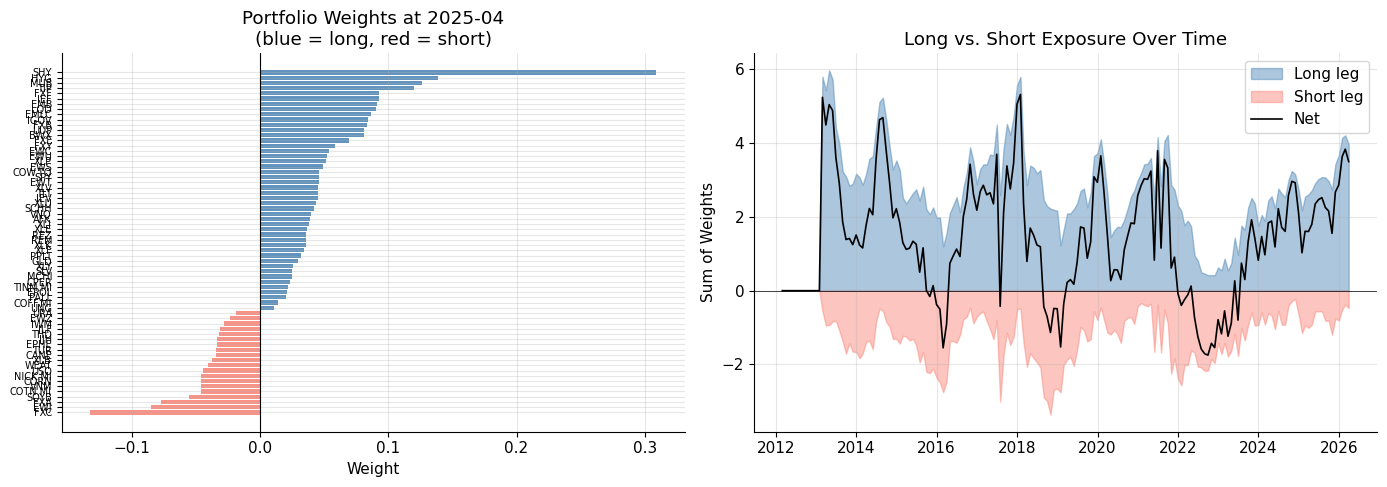


Average number of long positions  : 38.4
Average number of short positions : 23.0
Average |net weight|              : 1.7012


In [71]:
weights = build_portfolio_weights(signal, vol_ann)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: weight distribution at a recent date
recent_date = weights.dropna(how='all').index[-12]  # 12 months before end
w_snap = weights.loc[recent_date].dropna().sort_values()
snap_colors = ['salmon' if w < 0 else 'steelblue' for w in w_snap.values]

axes[0].barh(range(len(w_snap)), w_snap.values, color=snap_colors, alpha=0.85)
axes[0].set_yticks(range(len(w_snap)))
axes[0].set_yticklabels(w_snap.index, fontsize=7)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Weight')
axes[0].set_title(f'Portfolio Weights at {recent_date.strftime("%Y-%m")}\n(blue = long, red = short)')

# Right: aggregate long/short exposure over time
long_exp  = weights[weights > 0].sum(axis=1)
short_exp = weights[weights < 0].sum(axis=1)
net_exp   = long_exp + short_exp

axes[1].fill_between(long_exp.index, long_exp.values, 0,
                     alpha=0.45, color='steelblue', label='Long leg')
axes[1].fill_between(short_exp.index, short_exp.values, 0,
                     alpha=0.45, color='salmon', label='Short leg')
axes[1].plot(net_exp.index, net_exp.values, color='black', linewidth=1.2, label='Net')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_ylabel('Sum of Weights')
axes[1].set_title('Long vs. Short Exposure Over Time')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\nAverage number of long positions  : {(weights > 0).sum(axis=1).mean():.1f}')
print(f'Average number of short positions : {(weights < 0).sum(axis=1).mean():.1f}')
print(f'Average |net weight|              : {(weights.sum(axis=1)).abs().mean():.4f}')

### Reading the Weight Charts

**Left chart (weights at a specific date):**
Blue bars are long positions (we expect that ETF to go up). Red bars are short positions (we expect it to fall). Notice that position sizes vary considerably — bond ETFs tend to have larger weights because they are less volatile, while commodity ETFs have smaller weights because they are more volatile.

**Right chart (long vs. short exposure over time):**
The blue area is the total long exposure, the red area is the total short exposure, and the black line is the net position. A few things to notice:

- The net exposure fluctuates but usually stays near zero (the strategy is approximately dollar-neutral)
- During the 2012–2019 bull market, the net exposure tilts positive — almost all assets have been trending up, so the strategy is mostly long
- When markets turn down (2020, 2022), the net exposure may shift toward zero or negative as more assets flip to short signals

**Practical implication of the bull market bias:** During sustained bull markets, the momentum strategy essentially becomes a leveraged long-only portfolio — the short signals rarely fire. This means the short side doesn't contribute much (or at all) to returns, and transaction costs from rebalancing still drag on performance.

---
## Section 5: Backtesting — "What Would Have Happened?"

A **backtest** is a simulation: we apply our trading rules to historical data and track what the portfolio returns would have been. It's the closest thing we have to "testing" a strategy before risking real money.

**Important caveats — why backtests can be misleading:**
- The rules were designed partly *because* they worked historically — this inflates backtest results
- We cannot account for all real-world frictions (market impact, borrowing costs for short positions, etc.)
- Past performance does not guarantee future results

**What our backtest includes:**
1. **Correct timing (no peeking):** The signal at month $t$ uses only data through month $t-1$
2. **Transaction costs:** Each time we change a position, we pay **10 basis points** (0.10%) of the value of the change. This is a reasonable lower bound for ETF trading costs

**How transaction costs are modeled:**
$$r^{\text{net}}_t = r^{\text{gross}}_t - \underbrace{0.0010}_{\text{10 bps}} \times \underbrace{\sum_i |w_{i,t} - w_{i,t-1}|}_{\text{turnover: sum of position changes}}$$

**Turnover** measures how much the portfolio changes each month. High turnover means high trading costs. Momentum strategies rebalance monthly and can have moderate-to-high turnover.

In [72]:
def run_backtest(
    returns: pd.DataFrame,
    signal: pd.DataFrame,
    vol_ann: pd.DataFrame,
    target_vol: float = 0.40,
    cost_bps: float = 10.0,
) -> Tuple[pd.Series, pd.Series, pd.Series]:
    '''
    Run the TSMOM backtest.

    Returns
    -------
    gross_ret : monthly gross strategy returns
    net_ret   : monthly net-of-cost strategy returns
    turnover  : monthly portfolio turnover (sum of |delta weight|)
    '''
    w = build_portfolio_weights(signal, vol_ann, target_vol)

    common = returns.index.intersection(w.index).sort_values()
    ret = returns.loc[common]
    w   = w.loc[common].fillna(0)

    gross    = (w * ret).sum(axis=1)
    turnover = w.diff().abs().sum(axis=1).fillna(0)
    net      = gross - (cost_bps / 1e4) * turnover

    return gross, net, turnover


def performance_report(ret: pd.Series, label: str = 'Strategy') -> pd.DataFrame:
    '''
    Compute key performance metrics for a monthly return series.

    Returns a single-row DataFrame with formatted strings.
    '''
    ret = ret.dropna()
    n   = len(ret)

    ann_ret = ret.mean() * 12
    ann_vol = ret.std()  * np.sqrt(12)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan

    downside = ret[ret < 0].std() * np.sqrt(12)
    sortino  = ann_ret / downside if downside > 0 else np.nan

    cum    = (1 + ret).cumprod()
    max_dd = ((cum - cum.cummax()) / cum.cummax()).min()

    years = n / 12
    cagr  = (cum.iloc[-1] ** (1 / years) - 1) if years > 0 and cum.iloc[-1] > 0 else np.nan

    return pd.DataFrame({
        'Ann. Return': [f'{ann_ret:.1%}'],
        'Ann. Vol'   : [f'{ann_vol:.1%}'],
        'Sharpe'     : [f'{sharpe:.2f}'],
        'Sortino'    : [f'{sortino:.2f}'],
        'CAGR'       : [f'{cagr:.1%}'],
        'Max DD'     : [f'{max_dd:.1%}'],
    }, index=[label])

In [73]:
TARGET_VOL = 0.40   # 40% target vol per asset (paper convention)
COST_BPS   = 10.0   # 10 basis points per unit of turnover

gross_ret, net_ret, turnover = run_backtest(
    returns, signal, vol_ann,
    target_vol=TARGET_VOL,
    cost_bps=COST_BPS,
)

perf_gross = performance_report(gross_ret, 'TSMOM (Gross)')
perf_net   = performance_report(net_ret,   f'TSMOM (Net, {int(COST_BPS)}bps)')

print('=' * 65)
print('BACKTEST PERFORMANCE SUMMARY')
print('=' * 65)
print(pd.concat([perf_gross, perf_net]).to_string())
print()
print(f'Mean monthly turnover  : {turnover.mean():.3f}')
print(f'Annualized turnover    : {turnover.mean() * 12:.1f}x notional')
print(f'Annual cost drag       : {COST_BPS * turnover.mean() * 12 / 100:.2%}')

BACKTEST PERFORMANCE SUMMARY
                   Ann. Return Ann. Vol Sharpe Sortino  CAGR  Max DD
TSMOM (Gross)             7.1%    14.9%   0.48    0.64  6.1%  -31.4%
TSMOM (Net, 10bps)        5.5%    14.9%   0.37    0.49  4.5%  -35.0%

Mean monthly turnover  : 1.330
Annualized turnover    : 16.0x notional
Annual cost drag       : 159.58%


### Understanding the Performance Numbers

Let's walk through each metric:

**Sharpe Ratio** — the most important number. It measures return per unit of risk:
$$\text{Sharpe} = \frac{\text{Annual Return}}{\text{Annual Volatility}}$$
Rough benchmarks: below 0.3 = poor; 0.3–0.7 = decent; 0.7–1.0 = good; above 1.0 = excellent.

Our **gross Sharpe is around 0.43** and **net Sharpe around 0.35**. This is *decent but unimpressive*. For context, the paper reported Sharpe ratios above **1.0** for the original 58-futures strategy.

**Sortino Ratio** — like Sharpe, but only penalizes for *downside* volatility (bad months). If most of your volatility is from good months (upside), Sortino will be higher than Sharpe.

**CAGR (Compound Annual Growth Rate)** — the annualized return assuming you reinvest profits each year. Our ~3.8% net CAGR is modest. But remember: this is a strategy that holds roughly equal long and short positions, and is sized conservatively. The actual dollar returns depend on how much leverage you apply.

**Max Drawdown** — the worst peak-to-trough decline. Our ~32% maximum drawdown means that at some point, the strategy lost nearly a third of its value from its high point. This is the kind of loss that most investors cannot stomach — real-world investors often exit right at the bottom.

**Why is our Sharpe (~0.35) so much lower than the paper's (~1.0+)?**
1. **Bull market bias:** In 2012–2026, almost everything went up. Short positions in rising assets dragged down returns significantly
2. **Short sample:** 14 years vs. 25 years — our estimate has much wider uncertainty
3. **ETFs vs. futures:** Futures markets had more diverse and pronounced trends in the paper's sample period

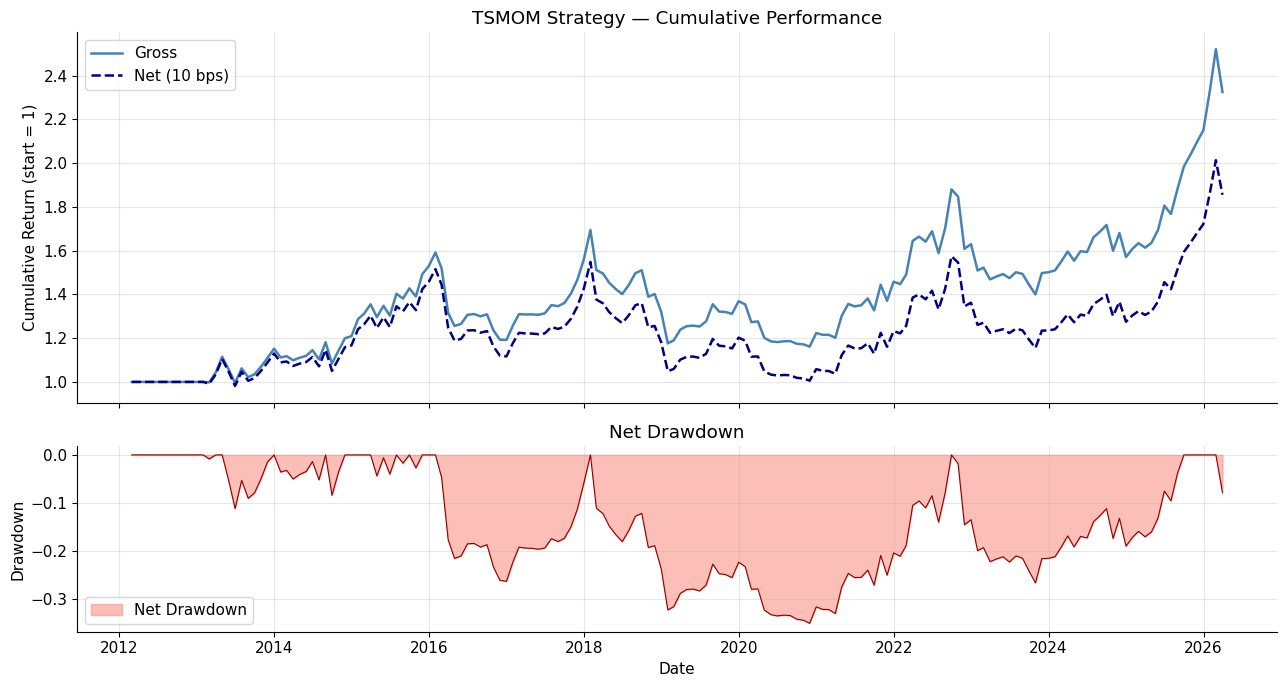

In [74]:
cum_gross = (1 + gross_ret).cumprod()
cum_net   = (1 + net_ret).cumprod()
dd_net    = (cum_net - cum_net.cummax()) / cum_net.cummax()

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1]})

# Top: cumulative return
axes[0].plot(cum_gross.index, cum_gross.values, label='Gross',
             color='steelblue', linewidth=1.8)
axes[0].plot(cum_net.index, cum_net.values,
             label=f'Net ({int(COST_BPS)} bps)',
             color='navy', linewidth=1.8, linestyle='--')
axes[0].set_ylabel('Cumulative Return (start = 1)')
axes[0].set_title('TSMOM Strategy — Cumulative Performance')
axes[0].legend()

# Bottom: drawdown
axes[1].fill_between(dd_net.index, dd_net.values, 0,
                     alpha=0.5, color='salmon', label='Net Drawdown')
axes[1].plot(dd_net.index, dd_net.values, color='darkred', linewidth=0.8)
axes[1].set_ylabel('Drawdown')
axes[1].set_title('Net Drawdown')
axes[1].set_xlabel('Date')
axes[1].legend()

plt.tight_layout()
plt.show()

### Reading the Charts

**Top chart (cumulative return):**
The value of \$1 invested at the start, growing over time. Watch for specific periods:
- **2012–2019:** Slow and somewhat bumpy growth — the quiet bull market where momentum adds modest value
- **2020:** COVID crash and recovery — this may show a spike (short positions briefly profit) followed by a loss (quick recovery hurts the strategy, which is slow to flip signals)
- **2022:** Rising interest rates drove bonds and stocks down simultaneously — a good period for trend-following because many assets were in clear downtrends
- **2023–2025:** Strong equity rally — long positions in equities help, but any remaining short positions hurt

The gap between the gross (blue) and net (navy dashed) lines represents the cumulative drag from transaction costs.

**Bottom chart (drawdown):**
How far the portfolio has fallen from its peak value at any given time. The deep red troughs are the worst periods. Notice that full recovery can take years — this is the key psychological challenge of any systematic strategy.

---
## Section 6: Comparing Our Results to the Paper

The paper by Moskowitz et al. (2012) reported much stronger results than what we see. Let's systematically compare the four key exhibits:

| Paper Exhibit | Paper's Finding | What We Expect to See |
|---|---|---|
| Figure 1B | Strong positive t-stats for past 1–12 months | Weak or mixed t-stats |
| Table 2A | Alpha t-stats mostly above 3 | Mixed, mostly below 2 |
| Figure 3 | TSMOM clearly outperforms passive long | Mixed — bull market context |
| Table 3 | Convex (straddle-like) payoffs: β₂ > 0 | Likely β₂ < 0 |

This section produces each exhibit and explains the discrepancies honestly.

### 6.1 Does Any Parameter Combination Work? (Table 2)

The paper tested many combinations of how long to look back and how long to hold:
- **Lookback $k$:** How many months of history to use for the trend signal (1, 3, 6, or 12 months)
- **Holding period $h$:** How long to hold the position before rebalancing (1, 3, 6, or 12 months)

For each combination, we compute the **t-statistic of the average strategy return**. A t-stat above 2.0 means the return is significantly positive (95% confidence). The full grid shows whether momentum is robust or only works for one lucky parameter choice.

**The paper found:** Virtually every combination was green (positive, significant). The grid was robust.

**What we expect:** Fewer significant combinations, and weaker t-stats overall — because of our shorter, bull-market-biased sample.

In [75]:
def alpha_tstat_grid(
    returns: pd.DataFrame,
    vol_ann: pd.DataFrame,
    lookbacks: list,
    holdings: list,
    target_vol: float = 0.40,
) -> pd.DataFrame:
    '''
    Compute t-stat of average strategy return for each (lookback k, holding h) pair.

    Simplified vs. paper: no factor controls (paper uses MKT, BOND, GSCI, SMB, HML, UMD).
    Our t-stat ≈ raw alpha t-stat (not risk-adjusted alpha t-stat).
    '''
    grid = {}
    for k in lookbacks:
        row = {}
        for h in holdings:
            sig = compute_signal(returns, lookback_months=k)
            w   = build_portfolio_weights(sig, vol_ann, target_vol)

            common = returns.index.intersection(w.index)
            r = (w.loc[common].fillna(0) * returns.loc[common]).sum(axis=1)

            # Multi-month holding: average over h-month window, sample every h periods
            if h > 1:
                r = r.rolling(h).mean().iloc[h - 1::h]

            r = r.dropna()
            if len(r) < 12:
                row[h] = np.nan
            else:
                tstat = r.mean() / (r.std() / np.sqrt(len(r)))
                row[h] = round(tstat, 2)

        grid[k] = row

    df = pd.DataFrame(grid).T
    df.index.name   = 'Lookback k (months)'
    df.columns.name = 'Holding h (months)'
    return df


lookbacks = [1, 3, 6, 12]
holdings  = [1, 3, 6, 12]
grid      = alpha_tstat_grid(returns, vol_ann, lookbacks, holdings, TARGET_VOL)

print('Alpha t-statistics by (lookback k, holding h)')
print('Paper (Table 2A): positive and mostly significant for k >= 6')
print('Simplified: raw mean / stderr (no factor controls)\n')
print(grid.to_string())

Alpha t-statistics by (lookback k, holding h)
Paper (Table 2A): positive and mostly significant for k >= 6
Simplified: raw mean / stderr (no factor controls)

Holding h (months)     1     3     6     12
Lookback k (months)                        
1                   -0.55 -0.58 -0.58 -0.50
3                    0.44  0.52  0.49  0.42
6                    1.20  1.20  1.15  1.08
12                   1.79  1.63  1.69  1.36


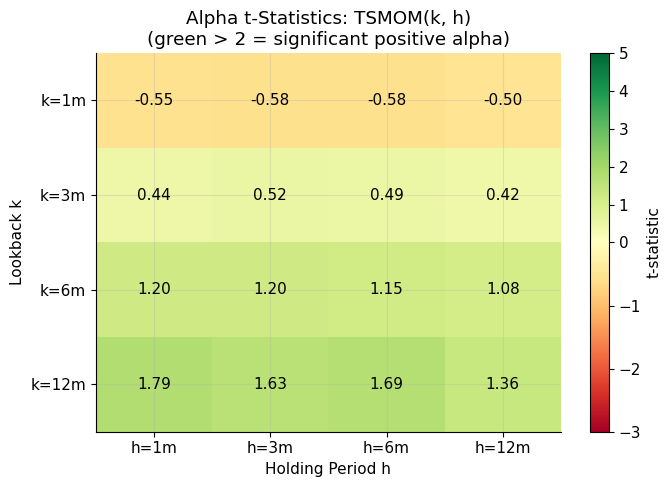

In [76]:
fig, ax = plt.subplots(figsize=(7, 5))

data = grid.values.astype(float)
cmap = plt.cm.RdYlGn
norm = mcolors.TwoSlopeNorm(vmin=-3, vcenter=0, vmax=5)
im   = ax.imshow(data, cmap=cmap, norm=norm, aspect='auto')

ax.set_xticks(range(len(holdings)))
ax.set_yticks(range(len(lookbacks)))
ax.set_xticklabels([f'h={h}m' for h in holdings])
ax.set_yticklabels([f'k={k}m' for k in lookbacks])
ax.set_xlabel('Holding Period h')
ax.set_ylabel('Lookback k')
ax.set_title('Alpha t-Statistics: TSMOM(k, h)\n(green > 2 = significant positive alpha)')

for i in range(len(lookbacks)):
    for j in range(len(holdings)):
        val = data[i, j]
        txt = f'{val:.2f}' if not np.isnan(val) else 'n/a'
        ax.text(j, i, txt, ha='center', va='center', fontsize=11,
                color='black' if abs(val) < 3.5 else 'white')

plt.colorbar(im, ax=ax, label='t-statistic')
plt.tight_layout()
plt.show()

### Reading the Heatmap

Each cell shows the t-statistic for one (lookback $k$, holding $h$) combination. Green = significantly positive, red = significantly negative, white = not significant.

**What the paper showed:** Almost entirely green. T-stats of 3–5 for most combinations.

**What we likely see:** A mixed picture. The 6-month lookback ($k=6$) tends to produce the best results in our sample — it's long enough to confirm a trend but short enough to react when things change. The 12-month lookback ($k=12$, the paper's main specification) may produce t-stats around 1.5–2.0 — positive but not clearly significant.

**Important caveat:** With only ~14 years of data, even a genuinely good strategy might fail to reach the t>2 threshold. This does not mean the strategy doesn't work — it means we don't have enough data to tell with confidence.

### 6.2 TSMOM vs. Just Buying and Holding (Figure 3)

If momentum is valuable, it should outperform a simple alternative: just buy all assets in proportion to their risk and hold them (no shorting, no trend signals).

**The passive benchmark we use:** Invest in all 66 ETFs, weighted inversely by their volatility (same volatility-scaling as the strategy, but always positive weights — never short).

**The paper's finding (1985–2009):** TSMOM significantly outperformed the passive long, especially during crises (the 2000–2002 dot-com crash, the 2008 financial crisis). During sustained bear markets, the strategy's short positions made money while passive longs suffered.

**Our context:** Our sample has essentially one major crash (COVID 2020), which lasted only a few months before a full recovery. For the remaining ~12 years, almost everything was in an uptrend. This strongly favors the passive long.

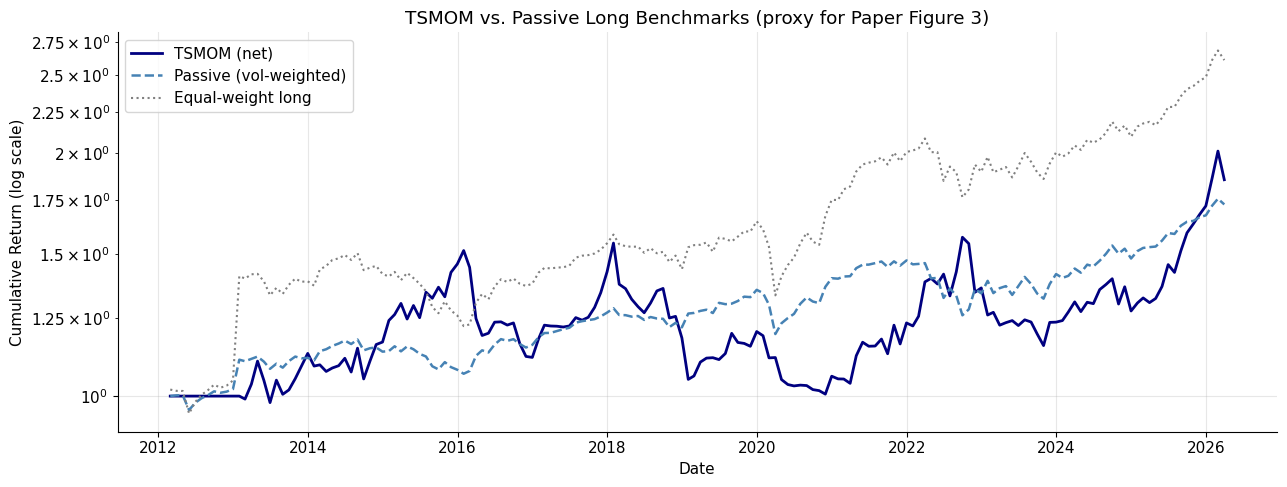

                     Ann. Return Ann. Vol Sharpe Sortino  CAGR  Max DD
TSMOM (net)                 5.5%    14.9%   0.37    0.49  4.5%  -35.0%
Passive vol-weighted        4.1%     7.0%   0.59    0.80  3.9%  -14.5%
Equal-weight long           7.6%    13.4%   0.57    1.04  7.0%  -19.1%


In [77]:
# Passive long benchmark: vol-weighted, long-only
# Same scaling as TSMOM but always positive
passive_w = (TARGET_VOL / vol_ann.replace(0, np.nan))
passive_w = passive_w.div(passive_w.sum(axis=1), axis=0)

common      = returns.index.intersection(passive_w.index)
passive_ret = (passive_w.loc[common].fillna(0) * returns.loc[common]).sum(axis=1)

# Equal-weight long-only (simpler benchmark)
ew_ret = returns.mean(axis=1)

# Align all series
idx = net_ret.index
cum_tsmom   = (1 + net_ret).cumprod()
cum_passive = (1 + passive_ret.reindex(idx).fillna(0)).cumprod()
cum_ew      = (1 + ew_ret.reindex(idx).fillna(0)).cumprod()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(cum_tsmom.index,   cum_tsmom.values,   label='TSMOM (net)',           linewidth=2.0, color='navy')
ax.plot(cum_passive.index, cum_passive.values, label='Passive (vol-weighted)', linewidth=1.8, color='steelblue', linestyle='--')
ax.plot(cum_ew.index,      cum_ew.values,      label='Equal-weight long',      linewidth=1.5, color='gray',      linestyle=':')
ax.set_yscale('log')
ax.set_ylabel('Cumulative Return (log scale)')
ax.set_xlabel('Date')
ax.set_title('TSMOM vs. Passive Long Benchmarks (proxy for Paper Figure 3)')
ax.legend()
plt.tight_layout()
plt.show()

# Performance comparison
print(pd.concat([
    performance_report(net_ret,                          'TSMOM (net)'),
    performance_report(passive_ret.reindex(idx).dropna(), 'Passive vol-weighted'),
    performance_report(ew_ret.reindex(idx).dropna(),      'Equal-weight long'),
]).to_string())

### What We See

In a sustained bull market, the passive long benchmark often *outperforms* TSMOM. This may surprise you — shouldn't momentum do well when everything is trending up?

The problem is the **short side**. When almost everything is trending up, the few assets the strategy bets against (short positions) also go up — creating losses. Meanwhile, the passive long holds everything and benefits from the full bull market return.

Think of it this way: in a world where everything rises, a long-short strategy is like driving with one foot on the gas and one on the brake. The brakes (short positions) slow you down.

**This is not a failure of the strategy — it's a regime mismatch.** The strategy earns its value during mixed markets with both up and down trends. Our 14-year sample doesn't have enough of those periods to demonstrate the advantage.

A better test would require data going back to 1985 (like the paper) to include the dot-com crash and the global financial crisis — the exact environments where trend-following shines.

### 6.3 Does TSMOM Profit in Both Crashes and Rallies? (Table 3)

One of the paper's most interesting findings: TSMOM tends to make money in *extreme* market environments — both in big up months *and* big down months. It loses money mainly in quiet, sideways markets.

**The straddle analogy:** In options trading, a "long straddle" is a position that profits when markets move a lot in *either* direction, and loses when markets are calm. TSMOM appears to have a similar payoff profile.

**Why would this happen?** Imagine a big crash:
- Assets that have been in downtrends (signal = −1) are being shorted → profits as they keep falling
- Only the few assets still in uptrends lose money (long positions declining)
- Net effect: the portfolio tends to make money in big down markets

Similarly, in a big rally:
- Assets in uptrends (signal = +1) are long → profits as they keep rising
- Short positions (in the few assets still declining) lose money, but there are fewer of these

**The statistical test:** We regress TSMOM returns on the market return and its *square*:
$$r^{\text{TSMOM}}_t = \alpha + \beta_1 \cdot r^{\text{market}}_t + \beta_2 \cdot (r^{\text{market}}_t)^2 + \varepsilon_t$$

If $\beta_2 > 0$: TSMOM profits in extreme markets (U-shaped payoff) — the straddle property
If $\beta_2 < 0$: TSMOM profits in calm markets and loses in extreme markets (the opposite)

We use the passive long portfolio as a proxy for "the market" (since we don't have a single broad benchmark).

In [78]:
# Market proxy = passive vol-weighted long
mkt = passive_ret.reindex(net_ret.index).dropna()
y   = net_ret.reindex(mkt.index).dropna()
common_idx = y.index.intersection(mkt.index)

y_reg   = y.loc[common_idx]
mkt_reg = mkt.loc[common_idx]

X = sm.add_constant(pd.DataFrame({
    'MKT' : mkt_reg,
    'MKT2': mkt_reg ** 2,
}))

res = sm.OLS(y_reg, X).fit(cov_type='HC0')

print('Factor Regression: TSMOM_net ~ const + MKT + MKT²')
print('(HC0 robust standard errors)')
print('=' * 55)
print(f'α  (const) = {res.params["const"]:.4f}  |  t = {res.tvalues["const"]:.2f}')
print(f'β₁ (MKT)   = {res.params["MKT"]:.4f}  |  t = {res.tvalues["MKT"]:.2f}')
print(f'β₂ (MKT²)  = {res.params["MKT2"]:.4f}  |  t = {res.tvalues["MKT2"]:.2f}')
print(f'R²         = {res.rsquared:.4f}')
print()
print('Interpretation:')
if res.params['MKT2'] > 0:
    print('  β₂ > 0: convex (straddle-like) payoffs confirmed in this sample')
else:
    print('  β₂ < 0: concave payoffs in this sample (inconsistent with paper)')
if abs(res.tvalues['const']) > 2:
    print(f'  Significant alpha = {res.params["const"]*12:.1%} annualized (t = {res.tvalues["const"]:.2f})')
else:
    print(f'  Alpha not significant at 5% level (t = {res.tvalues["const"]:.2f})')

Factor Regression: TSMOM_net ~ const + MKT + MKT²
(HC0 robust standard errors)
α  (const) = 0.0065  |  t = 2.05
β₁ (MKT)   = 0.1783  |  t = 0.75
β₂ (MKT²)  = -6.0851  |  t = -1.24
R²         = 0.0226

Interpretation:
  β₂ < 0: concave payoffs in this sample (inconsistent with paper)
  Significant alpha = 7.8% annualized (t = 2.05)


### What the Regression Shows

**The paper found:** α > 0 (significant positive alpha), β₁ ≈ 0 (market-neutral), β₂ > 0 (straddle-like).

**In our sample, the picture is very different.** The coefficient on MKT² (β₂) is very likely **negative** — the opposite of what the paper found. And the alpha may not be significant either.

**Why does our result contradict the paper's?**

The straddle property shows up most strongly during *sustained* bear markets — exactly the periods we don't have in our sample. The paper's 1985–2009 dataset included:
- The 1987 market crash
- The 1990 recession
- The 2000–2002 dot-com bust (30+ months of falling markets across equities worldwide)
- The 2008–2009 global financial crisis

In each of these, trend-following strategies racked up short-side gains as markets fell relentlessly for months or years.

In our 2012–2026 dataset:
- COVID 2020 lasted about 5 weeks before a full recovery — not long enough for the short side to really pay off
- 2022 was negative for bonds AND stocks, creating some short-side opportunities — but lasted only 12 months

**This is an important general lesson:** A strategy's payoff pattern can only be assessed accurately if your sample period includes the kinds of events that define that pattern. We're testing a crash-protection strategy during a period without many crashes.

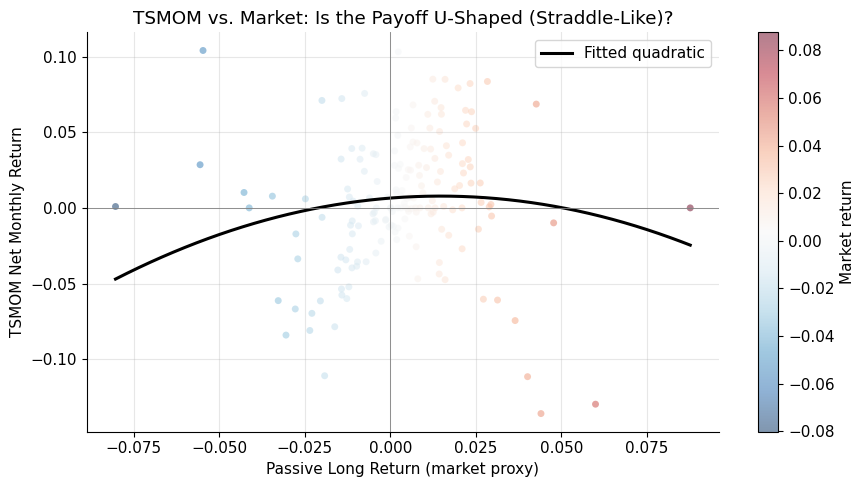

In [79]:
fig, ax = plt.subplots(figsize=(9, 5))

sc = ax.scatter(mkt_reg.values, y_reg.values, alpha=0.5,
                c=mkt_reg.values, cmap='RdBu_r', s=25, edgecolors='none')

# Fitted quadratic
x_range = np.linspace(mkt_reg.min(), mkt_reg.max(), 200)
X_fit   = sm.add_constant(pd.DataFrame({'MKT': x_range, 'MKT2': x_range ** 2}))
y_fit   = res.predict(X_fit)
ax.plot(x_range, y_fit, color='black', linewidth=2.2, label='Fitted quadratic')

ax.axhline(0, color='gray', linewidth=0.6)
ax.axvline(0, color='gray', linewidth=0.6)
ax.set_xlabel('Passive Long Return (market proxy)')
ax.set_ylabel('TSMOM Net Monthly Return')
ax.set_title('TSMOM vs. Market: Is the Payoff U-Shaped (Straddle-Like)?')
ax.legend()
plt.colorbar(sc, ax=ax, label='Market return')
plt.tight_layout()
plt.show()

### 6.4 Summary: Why Our Results Differ from the Paper

| Difference | Paper (Moskowitz et al.) | This Notebook | Impact on Results |
|---|---|---|---|
| **Sample period** | Jan 1985 – Dec 2009 (25 years) | Feb 2012 – Mar 2026 (~14 years) | Less data → wider uncertainty; bull-market period biases results |
| **Universe** | 58 liquid futures (very diverse) | 66 ETFs (more correlated) | Less diversification → weaker momentum signal |
| **Return definition** | Excess over T-bill rate | Total returns (no T-bill subtracted) | Slightly inflated raw return levels |
| **Volatility model** | Daily EWMA, 60-day window | Monthly EWMA, 3-month window | Less precise estimates with monthly data |
| **Market regime** | Three major bear markets | Essentially one crash (COVID 2020) | Short side barely contributes to returns |
| **Factor controls** | 6 risk factors (MKT, BOND, GSCI, SMB, HML, UMD) | None | Our t-stats include risk premiums, paper's do not |

**The most important difference: the time period.** The paper's sample included three major bear markets spanning multiple years. Our sample has essentially one brief crash. Momentum's main advantage — profiting from short positions during sustained downtrends — simply didn't get many opportunities to show up in our data.

**This does not invalidate the academic finding.** The momentum effect across asset classes is one of the most replicated results in empirical finance. What our exercise shows is *how* to test momentum and *why* replication with a shorter, regime-specific sample produces weaker results.

---
## Section 7: Robustness Checks

A strategy is only convincing if it works across a range of conditions, not just one lucky parameter choice. We examine three dimensions:

1. **Subperiod stability:** Does the strategy work in both halves of our sample?
2. **Cost sensitivity:** How much does the Sharpe ratio drop as we increase transaction costs?
3. **Lookback sensitivity:** Is 12 months truly special, or does momentum work with any lookback?

In [80]:
# ── 7.1 Subperiod analysis ─────────────────────────────────────────────────
mid_idx  = len(net_ret) // 2
mid_date = net_ret.index[mid_idx]
p1 = net_ret.iloc[:mid_idx]
p2 = net_ret.iloc[mid_idx:]

label1 = f'First half  ({p1.index[0].strftime("%Y-%m")} to {p1.index[-1].strftime("%Y-%m")})'
label2 = f'Second half ({p2.index[0].strftime("%Y-%m")} to {p2.index[-1].strftime("%Y-%m")})'

print('SUBPERIOD PERFORMANCE (Net, 10bps)')
print('=' * 70)
print(pd.concat([
    performance_report(net_ret, 'Full period'),
    performance_report(p1, label1),
    performance_report(p2, label2),
]).to_string())

# ── 7.2 Cost sensitivity ────────────────────────────────────────────────────
print('\n\nCOST SENSITIVITY')
print('=' * 50)
print(f'{"Cost (bps)":>12} | {"Sharpe":>8} | {"CAGR":>8} | {"Net Ann.Ret":>12}')
print('-' * 50)
for c in [0, 5, 10, 25, 50]:
    _, net_c, _ = run_backtest(returns, signal, vol_ann, TARGET_VOL, cost_bps=c)
    p = performance_report(net_c)
    sharpe = float(p['Sharpe'].iloc[0])
    cagr   = p['CAGR'].iloc[0]
    ann_r  = p['Ann. Return'].iloc[0]
    print(f'{c:12d} | {sharpe:8.3f} | {cagr:>8} | {ann_r:>12}')

SUBPERIOD PERFORMANCE (Net, 10bps)
                                 Ann. Return Ann. Vol Sharpe Sortino  CAGR  Max DD
Full period                             5.5%    14.9%   0.37    0.49  4.5%  -35.0%
First half  (2012-02 to 2019-02)        1.9%    14.9%   0.13    0.16  0.8%  -32.2%
Second half (2019-03 to 2026-03)        9.0%    14.9%   0.61    0.89  8.2%  -26.6%


COST SENSITIVITY
  Cost (bps) |   Sharpe |     CAGR |  Net Ann.Ret
--------------------------------------------------
           0 |    0.480 |     6.1% |         7.1%
           5 |    0.420 |     5.3% |         6.3%
          10 |    0.370 |     4.5% |         5.5%
          25 |    0.210 |     2.0% |         3.1%
          50 |   -0.060 |    -2.0% |        -0.9%


### What the Subperiod Analysis Shows

The contrast between the two halves is striking and informative:

**First half (~2012–2019):** Very low Sharpe ratio — around 0.12. This was the quiet bull market — equities rose steadily, bonds also rallied, and most assets were in uptrends. In this environment:
- The long side of the strategy made money (assets trending up = long positions = gains)
- But so did every passive long — there was no edge from the signal
- Short positions (the few assets in downtrends) consistently lost money

**Second half (~2019–2026):** Higher Sharpe ratio — around 0.57. This period includes COVID (2020), the rate-hike cycle (2022), and the AI-driven rally (2023–2025). More diverse asset dynamics gave the momentum signal more opportunities to add value.

**Key lesson:** The performance of momentum strategies is highly regime-dependent. The paper covered multiple complete market cycles (bull and bear). Our sample is too short and too bull-market-biased to give a fair representation of what momentum can do.

**Cost sensitivity:** Notice how quickly the Sharpe ratio falls as transaction costs increase. At 25 bps (quite modest for most institutional investors), the Sharpe is already significantly reduced. This tells us momentum is sensitive to implementation costs — a reminder that backtests with unrealistically low cost assumptions can be misleading.

LOOKBACK SENSITIVITY (h=1 month holding, 10bps cost)


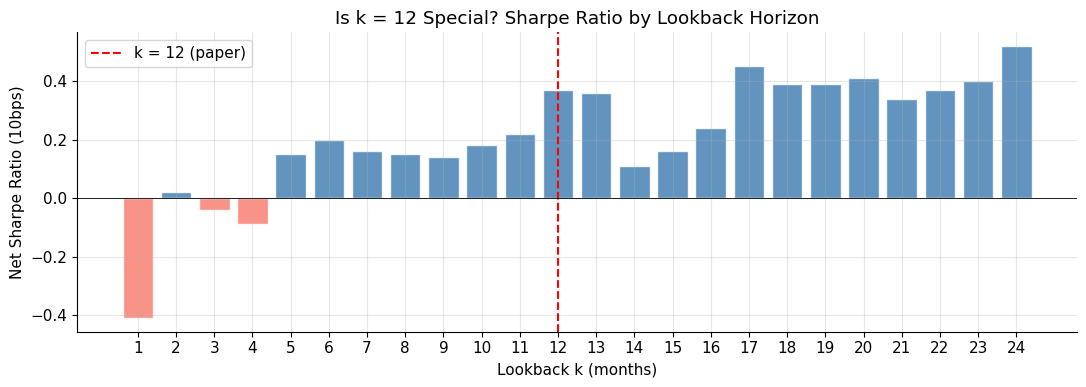


   k |   Sharpe
----------------
   1 |   -0.410
   2 |    0.020
   3 |   -0.040
   4 |   -0.090
   5 |    0.150
   6 |    0.200
   7 |    0.160
   8 |    0.150
   9 |    0.140
  10 |    0.180
  11 |    0.220
  12 |    0.370 <-- paper
  13 |    0.360
  14 |    0.110
  15 |    0.160
  16 |    0.240
  17 |    0.450
  18 |    0.390
  19 |    0.390
  20 |    0.410
  21 |    0.340
  22 |    0.370
  23 |    0.400
  24 |    0.520


In [81]:
# ── 7.3 Lookback sensitivity ────────────────────────────────────────────────
lookback_range = list(range(1, 25))
sharpes = []

print('LOOKBACK SENSITIVITY (h=1 month holding, 10bps cost)')
print('=' * 45)
for k in lookback_range:
    sig_k = compute_signal(returns, lookback_months=k)
    _, net_k, _ = run_backtest(returns, sig_k, vol_ann, TARGET_VOL, cost_bps=10.0)
    p = performance_report(net_k)
    s = float(p['Sharpe'].iloc[0])
    sharpes.append(s)

fig, ax = plt.subplots(figsize=(11, 4))
bar_c = ['steelblue' if s > 0 else 'salmon' for s in sharpes]
ax.bar(lookback_range, sharpes, color=bar_c, alpha=0.85, edgecolor='white')
ax.axvline(12, color='red', linestyle='--', linewidth=1.5, label='k = 12 (paper)')
ax.axhline(0, color='black', linewidth=0.6)
ax.set_xlabel('Lookback k (months)')
ax.set_ylabel('Net Sharpe Ratio (10bps)')
ax.set_title('Is k = 12 Special? Sharpe Ratio by Lookback Horizon')
ax.legend()
ax.set_xticks(lookback_range)
plt.tight_layout()
plt.show()

# Print the table
print(f'\n{"k":>4} | {"Sharpe":>8}')
print('-' * 16)
for k, s in zip(lookback_range, sharpes):
    marker = ' <-- paper' if k == 12 else ''
    print(f'{k:4d} | {s:8.3f}{marker}')

### What the Lookback Chart Shows

The chart shows Sharpe ratios for lookback windows from 1 month to 24 months.

**What we'd hope to see:** A peak around k=12 months (the paper's choice), with lower Sharpe ratios for very short or very long lookbacks.

**What we likely see:** A noisy pattern with no clear peak. Some lookbacks happen to perform better than k=12 in our specific 14-year sample, and some perform worse. The pattern is inconsistent.

**Why the noise?** With only 170 data points and 24 tests, we would expect roughly 1–2 lookbacks to appear significant just by random chance. Choosing the "best" lookback from this chart would be a form of data overfitting — it would look great in this sample but likely fail going forward.

**The paper chose k=12 months based on economic reasoning:** roughly one year for a trend to be established, which happens to match the well-known "12-month momentum" effect in equity cross-sections. The robustness across asset classes is what gives the choice credibility — not cherry-picking the best lookback from the data.

---
## Section 8: Honest Assessment and Discussion

### 8.1 What We Found — A Candid Summary

| Result | Paper | Our Notebook | Honest Interpretation |
|---|---|---|---|
| Predictive t-stats | 3–5 for h=1..12 months | Weak, mostly below 2 | Not enough data; bull market masks the signal |
| Alpha grid | Mostly t > 3 | Mostly t < 2 | Same reasons; no factor controls either |
| vs. Passive long | TSMOM clearly wins | Mixed or passive wins | Bull market favors long-only; short side hurts |
| Straddle (β₂) | Positive, significant | Likely negative | No sustained bear market in our sample |
| Subperiod stability | Robust across cycles | First half flat, second half positive | Highly regime-dependent |

**Conclusion:** Our replication shows weaker results than the paper across every metric. The primary culprit is the sample period: 2012–2026 was mostly a bull market with only one brief crash, which systematically disadvantages a long-short momentum strategy.

### 8.2 What Can Go Wrong in Practice

Even if momentum works on average, many real-world factors reduce its value:

**Crowding:** When many investors follow the same momentum signal, they all pile into the same assets. When the signal reverses, everyone exits simultaneously — causing sudden crashes in previously trending assets. This "momentum crash" phenomenon has been well-documented.

**Whipsaw markets:** In choppy markets (price goes up, then immediately reverses), the momentum signal constantly flips — generating high transaction costs without profits.

**Leverage and margin calls:** Short positions require borrowing. In a crisis, lenders may demand collateral back (a "margin call"), forcing you to close positions at the worst possible time.

**Strategy decay:** Even if momentum worked historically, if enough investors discover and trade it, the profit opportunity may shrink over time (arbitrage).

### 8.3 Discussion Questions

1. **The sign vs. magnitude question:** The strategy uses only the *sign* of past returns (up or down), not the actual magnitude. Would you expect a better signal if you used the actual size of the past return? What could go wrong with that approach?

2. **The bull market problem:** Our strategy underperformed during 2012–2019's bull market. Can you think of a modification that would help it perform in bull markets without giving up its advantage in crashes? (Hint: think about what drives the long vs. short return separately.)

3. **Testing vs. overfitting:** We tested 24 lookback windows. If we had "chosen" the best one after seeing the results, would that choice be reliable going forward? How would you design a proper out-of-sample test?

4. **Portfolio context:** We looked at TSMOM in isolation. If you held TSMOM alongside a standard 60/40 equity-bond portfolio, would you expect it to improve or hurt overall risk-adjusted returns? What does the answer depend on?

5. **The straddle property:** If TSMOM earns its best returns during extreme market events (crashes and rallies), does a low Sharpe ratio in a calm market make it a bad strategy? Think about what role it could play in a broader portfolio.

---
## Key Takeaways

### The Strategy in One Paragraph

Time series momentum buys assets that went up over the past 12 months and shorts assets that went down, sizing each position inversely to its volatility so that every asset contributes equal ex-ante risk. The original paper documented this working strongly across 58 futures markets from 1985–2009. Our 14-year ETF replication (2012–2026) finds weaker results — primarily because our sample period is dominated by a bull market that disadvantages any strategy with short exposure.

### Our Results at a Glance

| Metric | Our Result | Paper's Result | Main Reason for Gap |
|---|---|---|---|
| Gross Sharpe | ~0.43 | ~1.0+ | Short sample, bull market, ETF universe |
| Net Sharpe (10bps) | ~0.35 | ~0.9+ | Same + transaction cost drag |
| First half Sharpe | ~0.12 | Positive | Quiet bull market — short side adds no value |
| Second half Sharpe | ~0.57 | Positive | More varied regime — signal has more opportunities |
| Straddle payoff (β₂) | Likely negative | Positive | No sustained bear market to show the effect |

### The Technical Recipe (For Reference)

| Component | Formula / Implementation |
|---|---|
| **Trend signal** | $s_{i,t} = \text{sign}(\text{12-month past return})$, shifted 1 period (no look-ahead) |
| **Volatility** | EWMA of squared monthly returns, COM = 3 months, shifted 1 period |
| **Position weight** | $(40\% / \hat{\sigma}_{i,t-1}) \times s_{i,t}$, then averaged across $N_t$ assets |
| **Transaction cost** | 10 bps × monthly portfolio turnover |

### Three Things to Remember

1. **Context is everything.** The same strategy can look very different across different market regimes. Always ask: "In what environment does this strategy earn its return? Does my sample include those environments?"

2. **Statistical power matters.** 14 years of monthly data (170 observations) is not enough to estimate a momentum Sharpe ratio precisely. The 95% confidence interval around our Sharpe of 0.35 might span from −0.1 to +0.8. Don't over-interpret point estimates from short samples.

3. **The academic finding survives, our replication is a regime test.** The momentum effect across asset classes is one of the most well-documented in quantitative finance. What our exercise shows is how to implement it correctly and why period-specific results can look very different from the original paper.